In [24]:
from pathlib import Path

import numpy as np
import pandas as pd
import gzip
import json
import re
from collections import Counter
import matplotlib.pyplot as plt
from google.colab import drive
from matplotlib.patches import FancyBboxPatch, Circle, Ellipse, Polygon
from matplotlib.lines import Line2D

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.rcParams['figure.dpi'] = 140

**Electrode Coordinates**

In [21]:
drive.mount('/content/drive')
COORDINATE_FILE = "/content/drive/MyDrive/EEG_Project/Cap_Data/easycap_cac64_soterix_draft.csv"


coords = pd.read_csv(COORDINATE_FILE)
coords['status'] = coords['status'].str.lower().str.strip()
coords.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,label,x,y,status
0,Fp1,-1.313,4.746,blocked
1,Fp2,1.263,4.749,blocked
2,AF7,-2.413,4.126,blocked
3,AF3,-1.218,3.761,blocked
4,AFz,0.024,3.633,blocked


In [22]:
print(coords['status'].value_counts())
coords.sort_values(['status', 'y', 'x'], ascending=[True, False, True]).reset_index(drop=True)

status
blocked    66
open       46
Name: count, dtype: int64


,label,x,y,status
0,Fp2,1.263,4.749,blocked
1,Fp1,-1.313,4.746,blocked
2,AF7,-2.413,4.126,blocked
3,AF8,2.390,4.076,blocked
4,AF3,-1.218,3.761,blocked
...,...,...,...,...
107,PPO9h,-3.272,-2.969,open
108,POO2,0.667,-3.320,open
109,POO1,-0.621,-3.358,open
110,POO10h,2.164,-3.806,open


**Plot 2D Electrode Map**

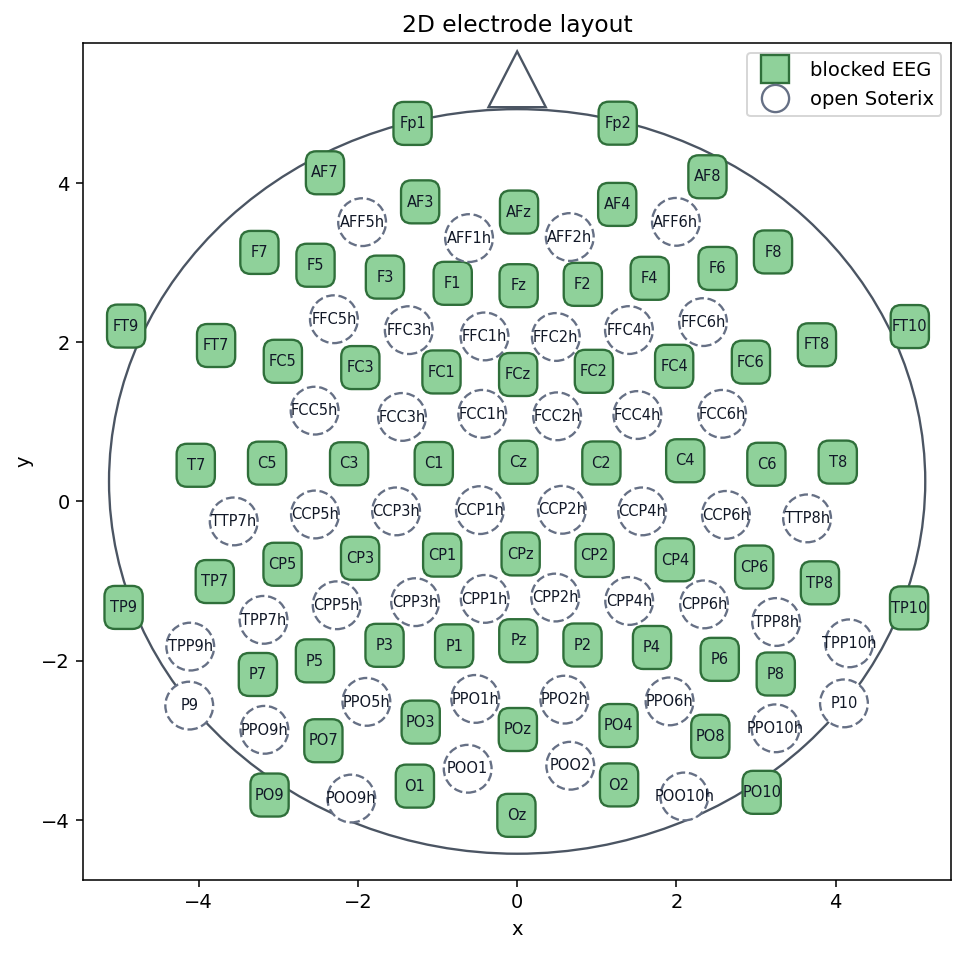

In [30]:
def apply_layout_tweaks(df):
    """
    Small coordinate corrections to better visually match the original
    EasyCap/Soterix layout. Returns a copy so the original dataframe is preserved.
    """
    plot_df = df.copy()

    # Pull lateral blocked EEG sites slightly inward
    lateral_blocked = [
        'FT7', 'FT8',
        'T7', 'T8',
        'TP7', 'TP8',
        'P7', 'P8',
        'F7', 'F8'
    ]
    plot_df.loc[plot_df['label'].isin(lateral_blocked), 'x'] *= 0.96

    # Move lower posterior region slightly upward
    lower_posterior = [
        'PO7', 'PO8',
        'PO9', 'PO10',
        'P9', 'P10',
        'PPO9h', 'PPO10h',
        'POO9h', 'POO10h'
    ]
    plot_df.loc[plot_df['label'].isin(lower_posterior), 'y'] += 0.10

    # Pull the lowest/lateral open Soterix sites slightly inward
    posterior_open = [
        'P9', 'P10',
        'PPO9h', 'PPO10h',
        'POO9h', 'POO10h'
    ]
    plot_df.loc[plot_df['label'].isin(posterior_open), 'x'] *= 0.97

    # Raise O1/O2 slightly so they sit closer to the original layout
    plot_df.loc[plot_df['label'].isin(['O1', 'O2']), 'y'] += 0.12

    return plot_df


def plot_2d_layout(
    df,
    title='2D electrode layout',
    target=None,
    highlight=None,
    show_head_outline=True,
    apply_tweaks=True,
    show_grid=False,
    show_axes=True
):
    highlight = set(highlight or [])

    # Use adjusted coordinates for plotting without overwriting original coords
    plot_df = apply_layout_tweaks(df) if apply_tweaks else df.copy()

    fig, ax = plt.subplots(figsize=(8, 8))

    open_df = plot_df[plot_df['status'] == 'open']
    blocked_df = plot_df[plot_df['status'] == 'blocked']

    # Final marker dimensions
    blocked_w = 0.48
    blocked_h = 0.54
    open_radius = 0.30

    # Head outline
    if show_head_outline:
        head = Ellipse(
            (0, 0.25),
            width=10.25,
            height=9.35,
            facecolor='none',
            edgecolor='#4b5563',
            linewidth=1.2,
            zorder=0
        )
        ax.add_patch(head)

        nose = Polygon(
            [[-0.36, 4.95], [0, 5.65], [0.36, 4.95]],
            closed=True,
            facecolor='none',
            edgecolor='#4b5563',
            linewidth=1.2,
            zorder=0
        )
        ax.add_patch(nose)

    # Blocked EEG sites: rounded, slightly vertical cap-like markers
    for row in blocked_df.itertuples():
        patch = FancyBboxPatch(
            (row.x - blocked_w / 2, row.y - blocked_h / 2),
            blocked_w,
            blocked_h,
            boxstyle="round,pad=0,rounding_size=0.13",
            facecolor='#8fd19a',
            edgecolor='#2f6f3a',
            linewidth=1.2,
            zorder=2
        )
        ax.add_patch(patch)

    # Open Soterix sites: dashed circles
    for row in open_df.itertuples():
        patch = Circle(
            (row.x, row.y),
            radius=open_radius,
            facecolor='white',
            edgecolor='#667085',
            linewidth=1.2,
            linestyle='--',
            zorder=2
        )
        ax.add_patch(patch)

    # Electrode labels
    for row in plot_df.itertuples():
        color = '#b42318' if row.label in highlight else '#111827'
        weight = 'bold' if row.label in highlight else 'normal'

        ax.text(
            row.x,
            row.y,
            row.label,
            ha='center',
            va='center',
            fontsize=7.5,
            color=color,
            fontweight=weight,
            zorder=3
        )

    # Optional target marker
    if target is not None:
        ax.scatter(
            [target['x']],
            [target['y']],
            s=440,
            marker='*',
            c='#f97316',
            edgecolor='black',
            linewidth=1.0,
            label=target['name'],
            zorder=4
        )

        ax.text(
            target['x'],
            target['y'] + 0.34,
            target['name'],
            ha='center',
            fontsize=9,
            fontweight='bold',
            zorder=5
        )

    # Manual legend
    legend_handles = [
        Line2D(
            [0],
            [0],
            marker='s',
            color='none',
            markerfacecolor='#8fd19a',
            markeredgecolor='#2f6f3a',
            markeredgewidth=1.2,
            markersize=14,
            label='blocked EEG'
        ),
        Line2D(
            [0],
            [0],
            marker='o',
            color='none',
            markerfacecolor='white',
            markeredgecolor='#667085',
            markeredgewidth=1.2,
            markersize=14,
            label='open Soterix'
        )
    ]

    ax.legend(handles=legend_handles, loc='upper right')

    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')

    # Final plot limits
    ax.set_xlim(-5.45, 5.45)
    ax.set_ylim(-4.75, 5.75)

    if show_grid:
        ax.grid(alpha=0.08)
    else:
        ax.grid(False)

    if show_axes:
        ax.set_xlabel('x')
        ax.set_ylabel('y')
    else:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_xticks([])
        ax.set_yticks([])

    return fig, ax, plot_df


# Development/checking view
fig, ax, coords_adjusted = plot_2d_layout(
    coords,
    show_grid=False,
    show_axes=True
)

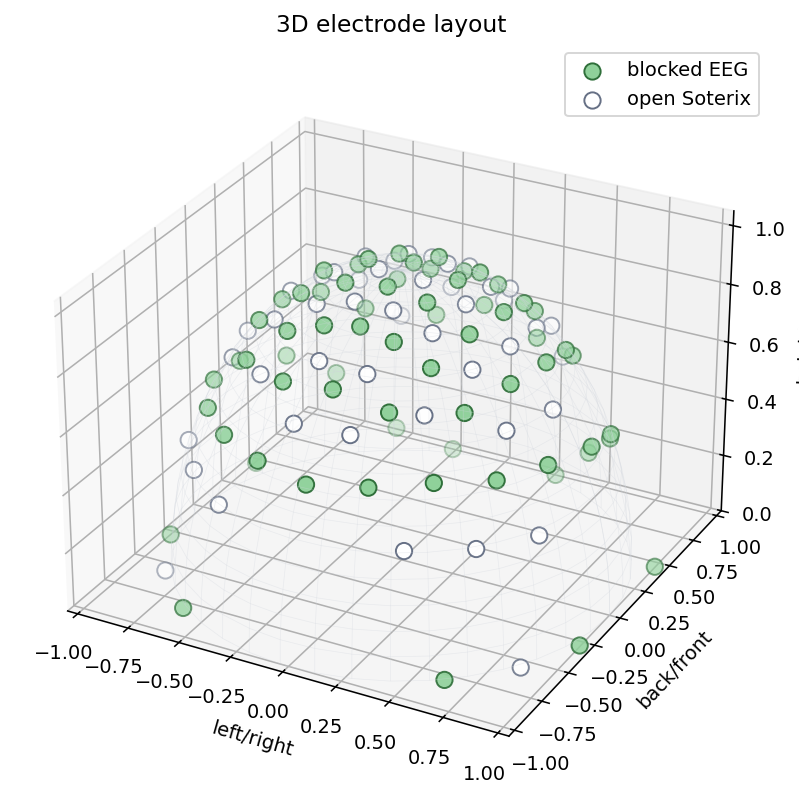

In [33]:
def add_dome_z(df):
    out = df.copy()

    # Normalize the 2D drawing into a unit circle, preserving the cap map's
    # left/right and front/back proportions as much as possible.
    x_scale = np.abs(out['x']).max()
    y_scale = np.abs(out['y']).max()
    out['x3'] = out['x'] / x_scale
    out['y3'] = out['y'] / y_scale

    radius = np.sqrt(out['x3'] ** 2 + out['y3'] ** 2)
    radius = np.clip(radius, 0, 1)
    out['z3'] = np.sqrt(1 - radius ** 2)
    return out

coords_3d = add_dome_z(coords)

def plot_3d_layout(df, title='3D electrode layout', label_subset=None):
    label_subset = set(label_subset or [])
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    open_df = df[df['status'] == 'open']
    blocked_df = df[df['status'] == 'blocked']

    ax.scatter(blocked_df['x3'], blocked_df['y3'], blocked_df['z3'], s=70, c='#8fd19a', edgecolor='#2f6f3a', label='blocked EEG')
    ax.scatter(open_df['x3'], open_df['y3'], open_df['z3'], s=70, facecolor='white', edgecolor='#667085', label='open Soterix')

    for row in df[df['label'].isin(label_subset)].itertuples():
        ax.text(row.x3, row.y3, row.z3 + 0.04, row.label, ha='center', fontsize=8, fontweight='bold')

    # Add a faint head dome so the point cloud has context.
    u = np.linspace(0, 2 * np.pi, 40)
    v = np.linspace(0, np.pi / 2, 20)
    dome_x = np.outer(np.cos(u), np.sin(v))
    dome_y = np.outer(np.sin(u), np.sin(v))
    dome_z = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(dome_x, dome_y, dome_z, color='#d0d5dd', linewidth=0.35, alpha=0.35)

    ax.set_title(title)
    ax.set_xlabel('left/right')
    ax.set_ylabel('back/front')
    ax.set_zlabel('height')
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.set_zlim(0, 1.05)
    ax.set_box_aspect((1, 1, 0.7))
    ax.view_init(elev=28, azim=-62)
    ax.legend(loc='upper right')


plot_3d_layout(coords_3d);

**Define Target Location**

Start with either a named cap site or a manual 2D coordinate. The target can be blocked; it is only the anatomical/geometric goal. Candidate stimulation sites are still selected from open Soterix positions only.

In [ ]:
def get_site_xy(df, label):
    matches = df[df['label'] == label]
    if matches.empty:
        raise ValueError(f'Unknown label: {label}')
    row = matches.iloc[0]
    return float(row['x']), float(row['y'])

# Option A: use an existing cap location as the target.
TARGET_LABEL = 'F3'
target_x, target_y = get_site_xy(coords, TARGET_LABEL)
target = {'name': TARGET_LABEL, 'x': target_x, 'y': target_y}

# Option B: manually enter a target coordinate instead.
# target = {'name': 'manual_target', 'x': -1.6, 'y': 2.8}

target


**Rank Single Open Soterix Sites**

This ranks only `status == open` positions. Blocked EEG sites remain on the map for reference but are not selected as stimulation positions.

In [ ]:
def distance_2d(x1, y1, x2, y2):
    return np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

def rank_single_open_sites(df, target):
    open_df = df[df['status'] == 'open'].copy()
    open_df['distance_to_target'] = distance_2d(
        open_df['x'], open_df['y'], target['x'], target['y']
    )
    open_df = open_df.sort_values('distance_to_target').reset_index(drop=True)
    open_df.insert(0, 'rank', np.arange(1, len(open_df) + 1))
    return open_df

ranked_single_electrodes = rank_single_open_sites(coords, target)
ranked_single_electrodes.head(15)


**Plot Target and Top Single-Site Candidates**

In [ ]:
top_single_labels = ranked_single_electrodes.head(10)['label'].tolist()
plot_2d_layout(
    coords,
    title='Target and nearest open Soterix sites',
    target=target,
    highlight=top_single_labels,
);


**Generate and Rank Simple Pair Montages**

This first pair model chooses an anode near the target and a cathode/reference site at a reasonable distance. It is intentionally geometry-only.

In [ ]:
def rank_pair_montages(
    df,
    target,
    candidate_anodes=12,
    ideal_separation=3.0,
    min_separation=1.0,
    max_separation=7.0,
):
    singles = rank_single_open_sites(df, target).head(candidate_anodes)
    open_df = df[df['status'] == 'open'].copy()

    rows = []
    for anode in singles.itertuples():
        for cathode in open_df.itertuples():
            if cathode.label == anode.label:
                continue

            separation = distance_2d(anode.x, anode.y, cathode.x, cathode.y)
            if separation < min_separation or separation > max_separation:
                continue

            separation_penalty = abs(separation - ideal_separation)
            score = (5.0 * anode.distance_to_target) + separation_penalty

            rows.append({
                'anode': anode.label,
                'cathode': cathode.label,
                'anode_distance_to_target': anode.distance_to_target,
                'inter_electrode_distance': separation,
                'score': score,
                'notes': f'anode near target; separation {separation:.2f} vs ideal {ideal_separation:.2f}',
            })

    ranked = pd.DataFrame(rows).sort_values('score').reset_index(drop=True)
    ranked.insert(0, 'rank', np.arange(1, len(ranked) + 1))
    return ranked

ranked_montages = rank_pair_montages(coords, target)
ranked_montages.head(20)


**Plot Top Pair Montage**

In [ ]:
def plot_pair_montage(df, target, montage_row, title='Top ranked pair montage'):
    labels = [montage_row['anode'], montage_row['cathode']]
    fig, ax = plot_2d_layout(
        df,
        title=title,
        target=target,
        highlight=labels,
    )

    plot_df = apply_layout_tweaks(df)
    points = plot_df.set_index('label')
    anode = points.loc[montage_row['anode']]
    cathode = points.loc[montage_row['cathode']]

    ax.scatter([anode.x], [anode.y], s=620, marker='o', facecolor='none', edgecolor='#b42318', linewidth=2.4, zorder=5)
    ax.scatter([cathode.x], [cathode.y], s=620, marker='o', facecolor='none', edgecolor='#175cd3', linewidth=2.4, zorder=5)
    ax.plot([anode.x, cathode.x], [anode.y, cathode.y], color='#475467', linewidth=1.6, zorder=4)

    ax.text(anode.x, anode.y + 0.43, 'anode', ha='center', color='#b42318', fontsize=8, fontweight='bold', zorder=6)
    ax.text(cathode.x, cathode.y + 0.43, 'cathode', ha='center', color='#175cd3', fontsize=8, fontweight='bold', zorder=6)
    return fig, ax

top_montage = ranked_montages.iloc[0]
plot_pair_montage(coords, target, top_montage);


**Review Ranking Outputs In Notebook**

No files are saved by this notebook. The ranking tables remain available as Colab variables: `ranked_single_electrodes` and `ranked_montages`.

In [ ]:
print('No files saved. Tables are available in memory as:')
print('- ranked_single_electrodes')
print('- ranked_montages')

display(ranked_single_electrodes.head(20))
display(ranked_montages.head(20))
